In [79]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


In [80]:
df = sns.load_dataset("titanic")

In [81]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [82]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [83]:
Feature = ["pclass","sex","fare", "embarked","age"]
target = ["survived"]

In [84]:
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])
imp_freq = SimpleImputer(strategy="most_frequent")

df[["embarked"]] = imp_freq.fit_transform(df[["embarked"]])

In [85]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [86]:
from sklearn.preprocessing import LabelEncoder
EC = LabelEncoder()

df["sex"] = EC.fit_transform(df["sex"])
df["embarked"]= EC.fit_transform(df["embarked"])

In [87]:
X = df[Feature]
y = df[target]

In [88]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, random_state=42 , test_size=0.2
)

In [89]:
Model = DecisionTreeClassifier()
Model.fit(X_train,y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [90]:
y_pred = Model.predict(X_test)
from sklearn.metrics import accuracy_score
print("accuracy_score", accuracy_score(y_test,y_pred))

accuracy_score 0.770949720670391


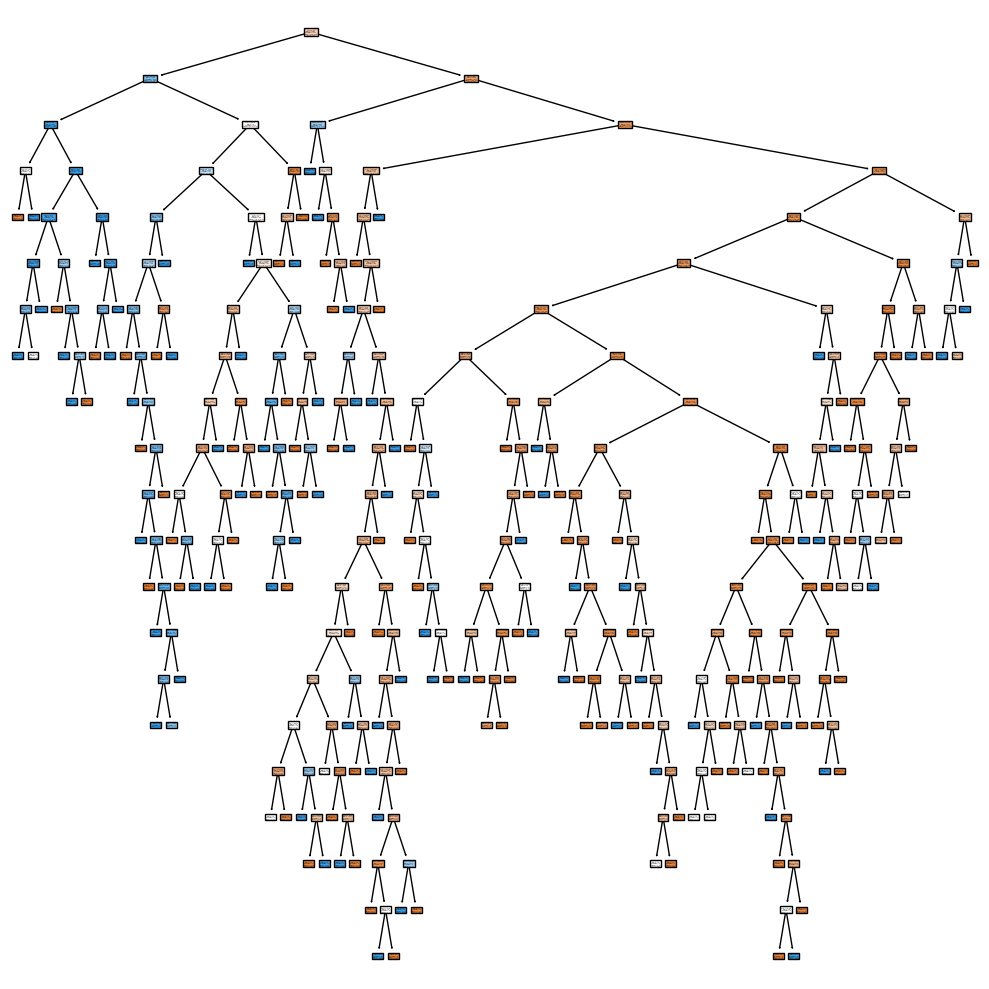

In [91]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(
    Model,
    feature_names = X.columns,
    class_names=["died","alived"],

    filled=True
)
plt.tight_layout()
plt.show()

In [92]:
from sklearn.tree import export_graphviz

In [93]:
export_graphviz(
    Model,
    out_file="data2.dot",
    feature_names=X.columns,
    class_names=["Died","Alive"],
    rounded= True,
    filled= True
)